In [1]:
import sys

sys.path.insert(0, "src")
import numpy as np
import partimorph as pm
from partimorph.analyzer import analyze_mask
from partimorph.utils import (
    create_circle_mask,
    create_ellipse_mask,
    create_rectangle_mask,
    create_square_mask,
    create_triangle_mask,
    create_pentagon_mask,
    create_star_mask,
    create_particle_mask,
    plot_analysis_results,
)

## 1. Geometric Mask Analysis
Analyzing various geometric shapes and sorting them by **Sphericity**.

=== CIRCLE ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.9977
  ● Aspect Ratio : 1.0037
  ● Circularity  : 0.9926
  ● Roundness    : 0.9920
-----------------------------------


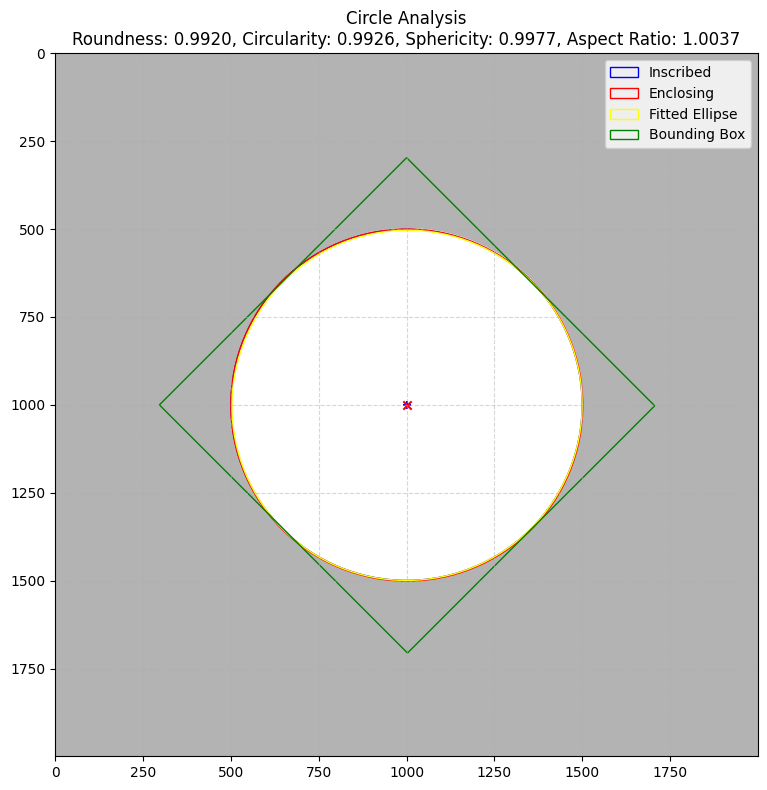

=== PENTAGON ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.8122
  ● Aspect Ratio : 1.0452
  ● Circularity  : 0.8695
  ● Roundness    : 0.1423
-----------------------------------


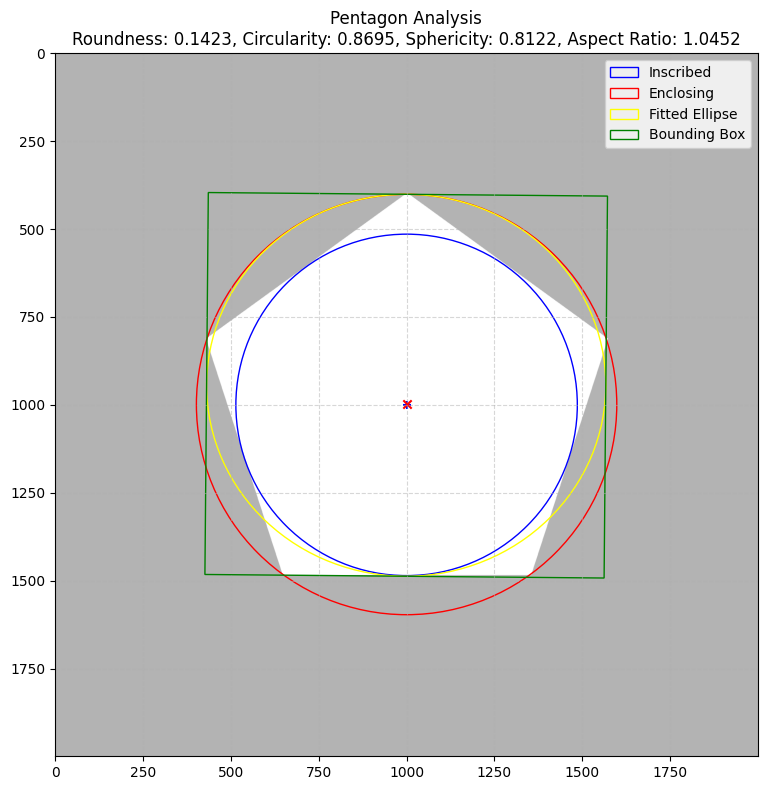

=== SQUARE ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.7164
  ● Aspect Ratio : 1.0000
  ● Circularity  : 0.8772
  ● Roundness    : 0.0929
-----------------------------------


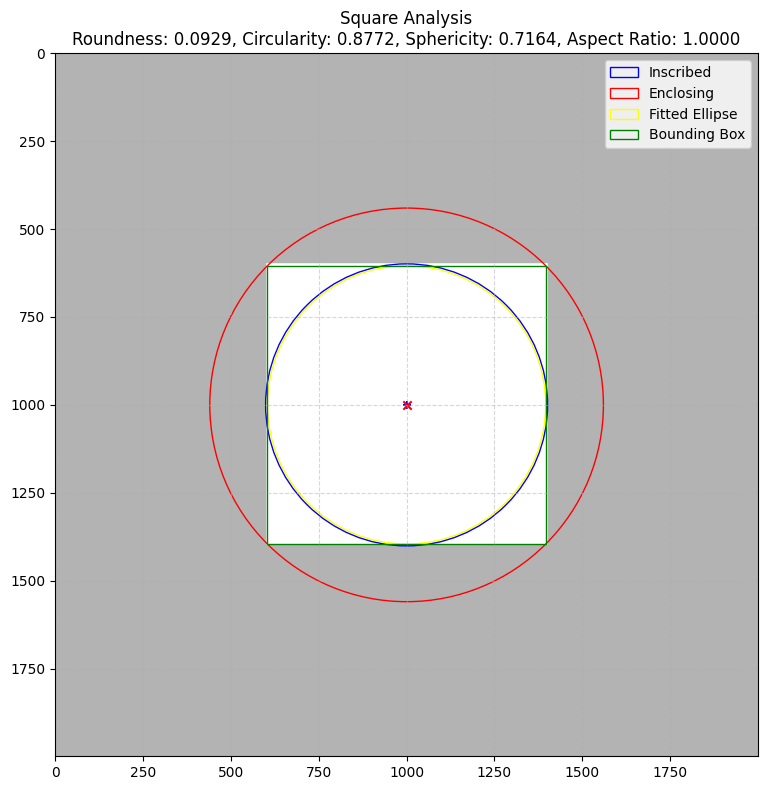

=== ELLIPSE ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.5740
  ● Aspect Ratio : 1.7631
  ● Circularity  : 0.8937
  ● Roundness    : 0.6818
-----------------------------------


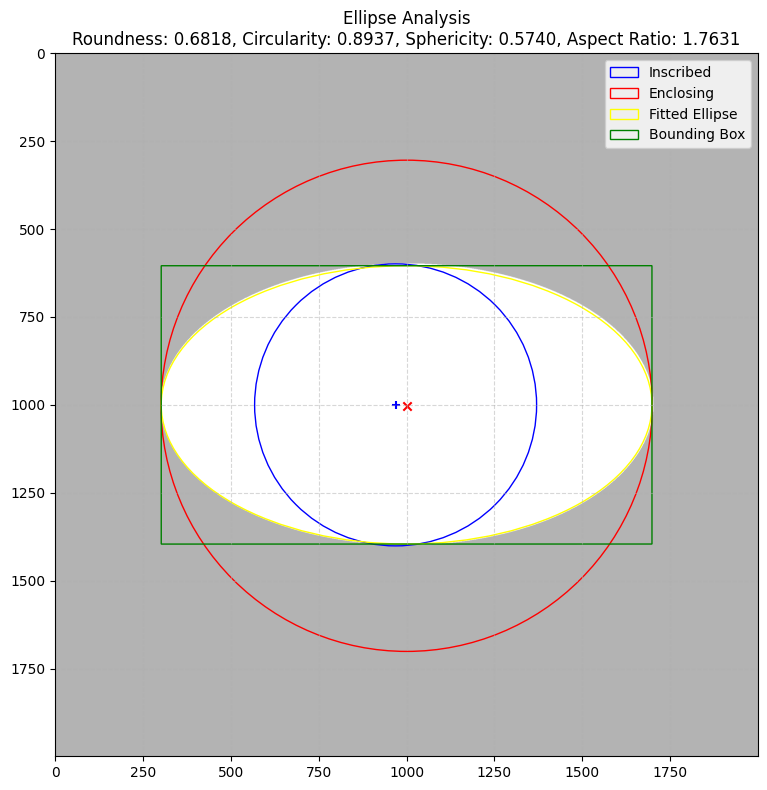

=== RECTANGLE ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.5586
  ● Aspect Ratio : 1.5132
  ● Circularity  : 0.8403
  ● Roundness    : 0.1123
-----------------------------------


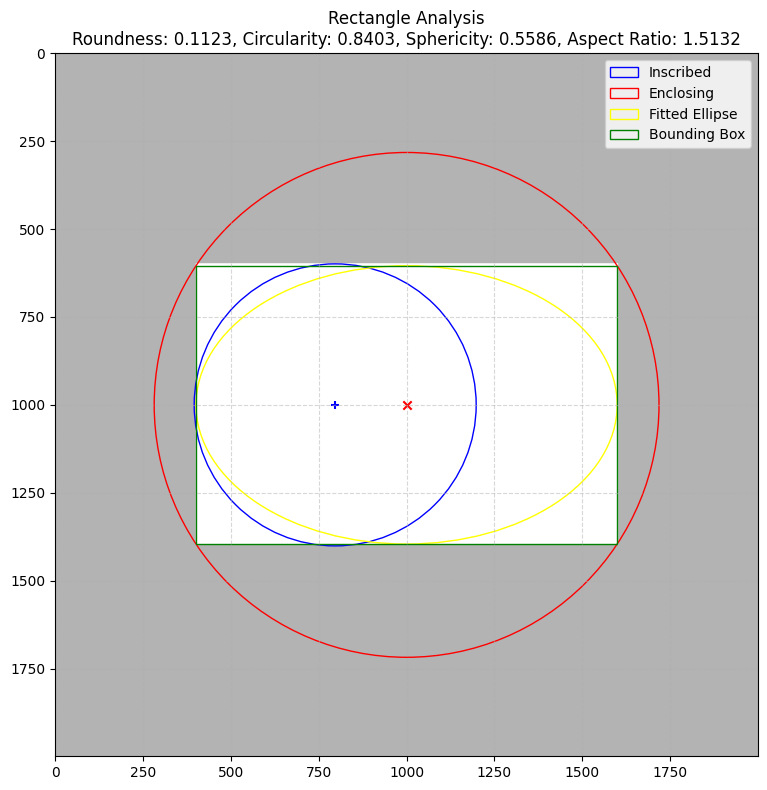

=== TRIANGLE ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.4978
  ● Aspect Ratio : 1.0000
  ● Circularity  : 0.6006
  ● Roundness    : 0.0487
-----------------------------------


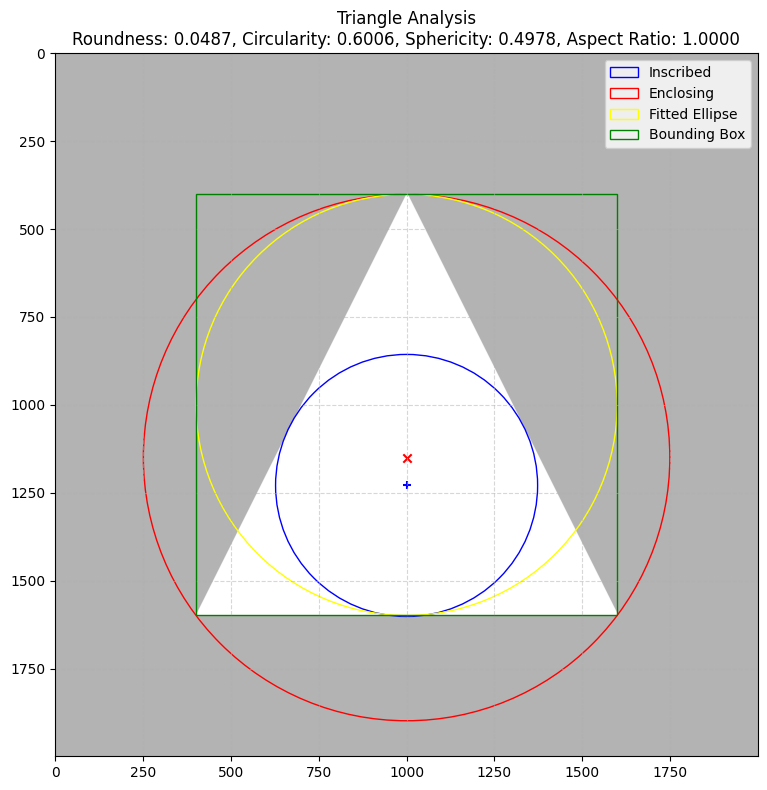

=== STAR ANALYSIS ===
  [Metrics]
  ● Sphericity   : 0.4333
  ● Aspect Ratio : 1.0468
  ● Circularity  : 0.3258
  ● Roundness    : 0.0505
-----------------------------------


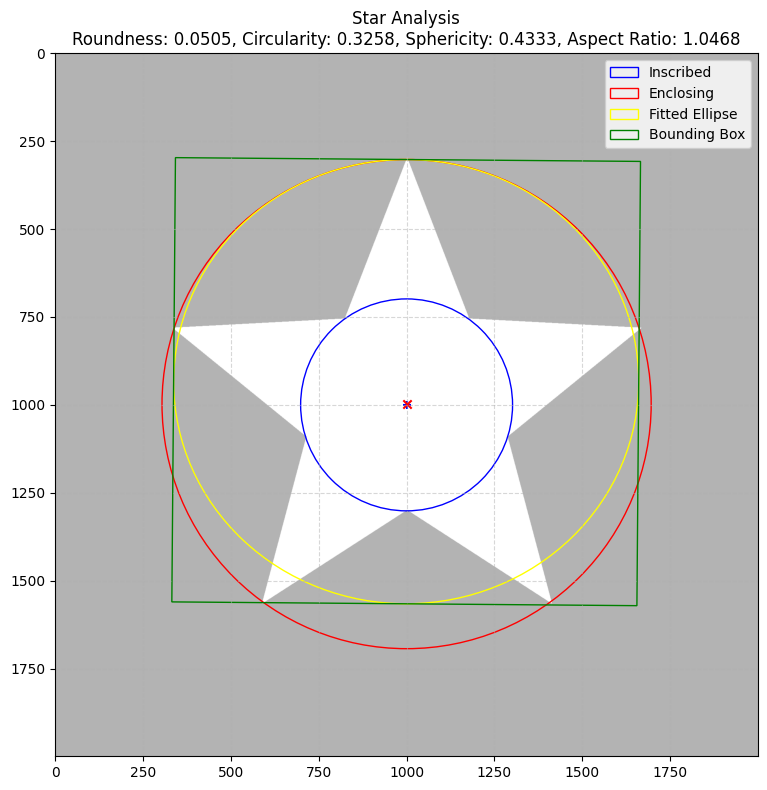

In [2]:
shape = (2000, 2000)
masks = [
    ("Circle", create_circle_mask(shape, center=(1000, 1000), radius=500)),
    (
        "Ellipse",
        create_ellipse_mask(shape, center=(1000, 1000), radius_x=700, radius_y=400),
    ),
    (
        "Rectangle",
        create_rectangle_mask(shape, top_left=(600, 400), bottom_right=(1400, 1600)),
    ),
    ("Square", create_square_mask(shape, top_left=(600, 600), size=800)),
    (
        "Triangle",
        create_triangle_mask(shape, v1=(400, 1600), v2=(1600, 1600), v3=(1000, 400)),
    ),
    ("Pentagon", create_pentagon_mask(shape, center=(1000, 1000), radius=600)),
    (
        "Star",
        create_star_mask(
            shape, center=(1000, 1000), outer_radius=700, inner_radius=300
        ),
    ),
]

results_list = []
for name, mask in masks:
    res = analyze_mask(mask)
    s_val = res["sphericity"]["val"] if res.get("sphericity") else 0.0

    results_list.append(
        {"name": name, "mask": mask, "results": res, "sphericity": s_val}
    )

# Sort by Sphericity (Descending)
results_list.sort(key=lambda x: x["sphericity"], reverse=True)

for item in results_list:
    r = item["results"]

    def _get_val(data):
        return data.get("val", 0.0) if data else 0.0

    s = _get_val(r.get("sphericity"))
    ar = _get_val(r.get("aspect_ratio"))
    c = _get_val(r.get("circularity"))
    ro = _get_val(r.get("roundness"))

    print(f"=== {item['name'].upper()} ANALYSIS ===")
    print(f"  [Metrics]")
    print(f"  ● Sphericity   : {s:.4f}")
    print(f"  ● Aspect Ratio : {ar:.4f}")
    print(f"  ● Circularity  : {c:.4f}")
    print(f"  ● Roundness    : {ro:.4f}")
    print("-" * 35)

    plot_analysis_results(
        item["mask"], item["results"], title=f"{item['name']} Analysis"
    )

## 2. Parametric (Fourier) Mask Test
Generating a custom particle using Fourier descriptors and comparing target vs. achieved metrics.

--- Metric Comparison (Target vs. Achieved) ---
Sphericity : Target 0.7500, Achieved 0.7478, Error -0.0022
Roundness  : Target 0.8000, Achieved 0.7930, Error -0.0070
--------------------------------------------------


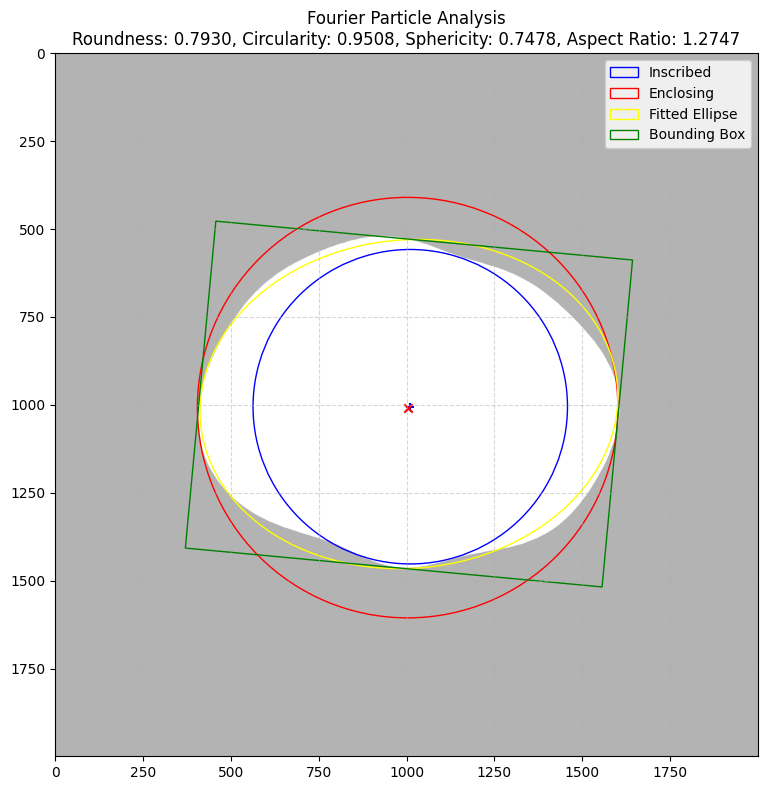

In [3]:
target_s = 0.75
target_r = 0.8

mask, info = create_particle_mask(
    shape=(2000, 2000),
    center=(1000, 1000),
    sphericity=target_s,
    roundness=target_r,
    radius=600,
    return_info=True,
)

results = analyze_mask(mask)

# Extract achieved values
achieved_s = results.get("sphericity", {}).get("val", 0.0)
achieved_r = results.get("roundness", {}).get("val", 0.0)

# Calculate errors
err_s = achieved_s - target_s
err_r = achieved_r - target_r

print("--- Metric Comparison (Target vs. Achieved) ---")
print(
    f"Sphericity : Target {target_s:.4f}, Achieved {achieved_s:.4f}, Error {err_s:+.4f}"
)
print(
    f"Roundness  : Target {target_r:.4f}, Achieved {achieved_r:.4f}, Error {err_r:+.4f}"
)
print("-" * 50)

plot_analysis_results(mask, results, title="Fourier Particle Analysis")